# Machine Learning with Python

## Final Exam

The file `heart_disease.csv` contains data on a cohort of patients with and without heart disease, as described at https://archive.ics.uci.edu/dataset/45/heart+disease .

The final column in the data table (labelled `num`) gives a numerical indication of the severity of the patient's heart disease, from 0 (no disease is present) up to 4.

Note that some of the features may contain missing data, indicated by `?`.

In [ ]:
# %pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_absolute_error,mean_squared_error,max_error,explained_variance_score,r2_score

## 1.
Load the data and prepare training and testing datasets ready for a binary classifier, i.e. you should simply predict whether disease is absent (`num`=0) or present (`num`=1,2,3 or 4).

In [158]:
heart_disease = pd.read_csv("heart_disease.csv")
# display(heart_disease)

heart_disease.replace('?', np.nan, inplace=True)

X = heart_disease.iloc[ : , :13]
# display(X)


## ENCODE cp
#setting sparse=False means that enc.transform() will return an array
enc = OneHotEncoder( sparse_output=False )

# fit the encoder to the data
enc.fit(X[["cp"]])

# encode the data
subject_enc = enc.transform(X[["cp"]])

# print(subject_enc)

new_columns = pd.DataFrame(subject_enc, columns=["cp_" + str(cat) for cat in enc.categories_[0]])

# print(new_columns)

# remove the original "subject" feature and add the new features
X_enc = X.drop("cp",axis=1).join(new_columns)


## ENCODE restecg
#setting sparse=False means that enc.transform() will return an array
enc = OneHotEncoder( sparse_output=False )

# fit the encoder to the data
enc.fit(X_enc[["restecg"]])

# encode the data
subject_enc = enc.transform(X[["restecg"]])

# print(subject_enc)

new_columns = pd.DataFrame(subject_enc, columns=["restecg_" + str(cat) for cat in enc.categories_[0]])

# print(new_columns)

# remove the original "subject" feature and add the new features
X_enc = X_enc.drop("restecg",axis=1).join(new_columns)


## ENCODE slope
#setting sparse=False means that enc.transform() will return an array
enc = OneHotEncoder( sparse_output=False )

# fit the encoder to the data
enc.fit(X_enc[["slope"]])

# encode the data
subject_enc = enc.transform(X[["slope"]])

# print(subject_enc)

new_columns = pd.DataFrame(subject_enc, columns=["slope_" + str(cat) for cat in enc.categories_[0]])

# print(new_columns)

# remove the original "subject" feature and add the new features
X_enc = X_enc.drop("slope",axis=1).join(new_columns)


## ENCODE thal
# Create a copy of the column to handle NaNs separately
X_enc['thal_temp'] = X_enc['thal'].fillna('missing')  # Fill NaNs with a placeholder (e.g., 'missing')

# Fit the encoder to the data
enc = OneHotEncoder(sparse_output=False)

# Fit and transform the 'thal_temp' column (with placeholder for NaNs)
enc.fit(X_enc[["thal_temp"]])

# Encode the data
subject_enc = enc.transform(X_enc[["thal_temp"]])

# Create new columns with one-hot encoded values
new_columns = pd.DataFrame(subject_enc, columns=["thal_" + str(cat) for cat in enc.categories_[0]])

# Replace 'missing' back to NaN
new_columns.loc[new_columns['thal_missing'] == 1, :] = np.nan  # Set rows corresponding to 'missing' back to NaN

# remove the original "subject" feature and add the new features
X_enc = X_enc.drop("thal",axis=1).join(new_columns)
X_enc = X_enc.drop('thal_temp', axis=1)
X_enc = X_enc.drop('thal_missing', axis=1)

# display(X_enc)

# FORMAT y
y = heart_disease['num'].apply(lambda x: 1 if x >= 1 else 0)
# display(y)

## TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, random_state=0
)
# display(X_test)

## IMPUTE NAs
imp = IterativeImputer()
imp.fit(X_train)
X_train_imp = imp.transform(X_train)

# Convert the output back to a DataFrame with the original column names
X_train_imp_df = pd.DataFrame(X_train_imp, columns=X_train.columns)

categorical_columns = ['sex', 'fbs', 'exang', 'ca', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0',
                       'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'slope_1.0', 'slope_2.0', 'slope_3.0',
                       'thal_3.0', 'thal_6.0', 'thal_7.0']  # Columns to round after imputation

X_train_imp_df[categorical_columns] = X_train_imp_df[categorical_columns].round()

# X_train_imp_df["sum_last_3"] = X_train_imp_df.iloc[:, -3:].sum(axis=1)

# display(X_train_imp_df)
# tmp = X_train_imp_df[X_train_imp_df["sum_last_3"] != 1.0]
# display(tmp)

## SCALE CONTINUOUS VARIABLES
# List of columns to scale
columns_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform only the selected columns
X_train_scaled = scaler.fit_transform(X_train_imp_df[columns_to_scale])

# Convert scaled values back to a DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=columns_to_scale)

# Replace scaled columns in the original DataFrame
X_train = X_train_imp_df.copy()  # Copy original DataFrame
X_train[columns_to_scale] = X_train_scaled_df  # Replace only the specified columns

# Display the final DataFrame
# display(X_train)


### TEST DATA

# Impute and scale test data
X_test_imp = imp.transform(X_test)

# Convert the output back to a DataFrame with the original column names
X_test_imp_df = pd.DataFrame(X_test_imp, columns=X_test.columns)

# X_test_imp_df["sum_last_3"] = X_test_imp_df.iloc[:, -3:].sum(axis=1)

# # display(X_test_imp_df)
# tmp = X_test_imp_df[X_test_imp_df["sum_last_3"] != 1.0]
# display(tmp)

categorical_columns = ['sex', 'fbs', 'exang', 'ca', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0',
                       'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'slope_1.0', 'slope_2.0', 'slope_3.0',
                       'thal_3.0', 'thal_6.0', 'thal_7.0']  # Columns to round after imputation

X_test_imp_df[categorical_columns] = X_test_imp_df[categorical_columns].round()

# Fit and transform only the selected columns
X_test_scaled = scaler.transform(X_test_imp_df[columns_to_scale])

# Convert scaled values back to a DataFrame
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=columns_to_scale)

# Replace scaled columns in the original DataFrame
X_test = X_test_imp_df.copy()  # Copy original DataFrame
X_test[columns_to_scale] = X_test_scaled_df  # Replace only the specified columns

# display(X_test)

## 2.
Using 5-fold cross-validation, estimate the performance of a random forest classifier on the training data.

In [156]:
rf = RandomForestClassifier(n_estimators=100,random_state=0)

# Impute for all data
# display(X_enc)
imp = IterativeImputer()
imp.fit(X_enc)
X_imp = imp.transform(X_enc)

# Convert the output back to a DataFrame with the original column names
X_imp_df = pd.DataFrame(X_imp, columns=X_enc.columns)

X_imp_df[categorical_columns] = X_imp_df[categorical_columns].round()

# display(X_imp_df)

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform only the selected columns
X_scaled = scaler.fit_transform(X_imp_df[columns_to_scale])

# Convert scaled values back to a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=columns_to_scale)

# Replace scaled columns in the original DataFrame
X = X_imp_df.copy()  # Copy original DataFrame
X[columns_to_scale] = X_scaled_df  # Replace only the specified columns
# display(X)
# display(y)

score = cross_val_score(rf,X,y,cv=5,scoring='r2' )
print("Cross-validated r2:")
print(score)
print("mean r2 =", np.mean(score))
print("sd =", np.std(score))

Cross-validated r2:
[0.47186147 0.47186147 0.07575758 0.32659933 0.0625    ]
mean r2 = 0.2817159692159693
sd = 0.18154869380851132


## 3.
Train your classifier on the full training dataset and evaluate its performance on the testing dataset.

In [157]:
rf = RandomForestClassifier(n_estimators=100,random_state=0)

rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
print( "accuracy =", np.mean(y_pred == y_test))
importances = rf.feature_importances_
print(importances)
print( classification_report(y_test,y_pred) )

accuracy = 0.75
[0.08954952 0.01683811 0.07266332 0.06625617 0.00963912 0.12222164
 0.05628332 0.09319852 0.0609301  0.01015285 0.01543212 0.02177897
 0.07973308 0.01468989 0.00149317 0.01110435 0.0420168  0.03781444
 0.00500862 0.08147539 0.00647752 0.08524298]
              precision    recall  f1-score   support

           0       0.72      0.85      0.78        40
           1       0.79      0.64      0.71        36

    accuracy                           0.75        76
   macro avg       0.76      0.74      0.74        76
weighted avg       0.76      0.75      0.75        76



## 4.
Plot the ROC curve for your final classifier using the testing dataset.

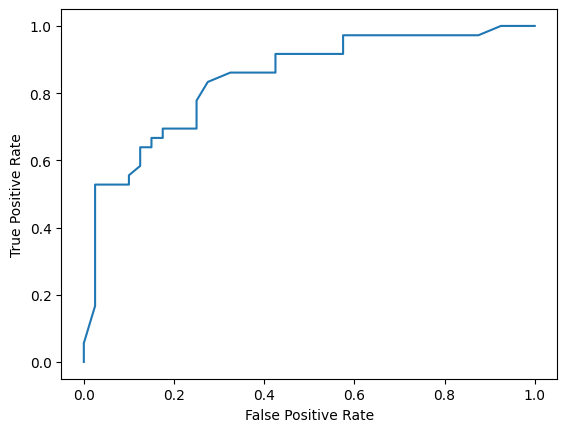

AUC = 0.8434027777777778


In [152]:
probs = rf.predict_proba(X_test)
fpr,tpr,thresholds = roc_curve(y_test,probs[:,1])

plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

auc = roc_auc_score(y_test,probs[:,1])
print("AUC =",auc)

---